# Joint hydraulic distribution analysis


`Lsf_overtopping.py` is used for:

- Hydra-NL marginal return levels;
- directional co-occurrence data;
- Gumbel fitting;
- the SWL–$H_{m0}$ dependence model;
- the Gaussian copula;
- the $H_{m0}$–$T_{m-1,0}$ relation;
- the EurOtop overtopping model;
- overtopping and overflow limit-state functions.

Keep this notebook in the same project folder as `Lsf_overtopping.py`, `Parameters.py`, and `Probabilistic.py`.

## 1. Imports and settings

In [13]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openturns as ot
from scipy.stats import norm, beta as beta_distribution

import Parameters as P
from Probabilistic import input_OpenTurns, run_FORM_analysis

from Lsf_overtopping import (
    RETURN_PERIOD_YR,
    SWL_RETURN_LEVEL,
    HM0_RETURN_LEVEL,
    TM_RETURN_LEVEL,
    project_structure_config,
    fit_hydra_margins,
    spearman_to_gaussian_copula_rho,
    cooccurrence_dependence_table,
    estimate_gaussian_copula_rho_from_cooccurrence,
    DEFAULT_SPEARMAN_RHO,
    build_openturns_hydraulic_distribution,
    derive_tm_from_hm0,
    compute_q,
)

ot.Log.Show(ot.Log.NONE)

OUTPUT_DIR = "results"
SAVE_FIGURES = True
SHOW_PLOTS = True
RUN_FORM = False

RANDOM_SEED = 42
PLOT_SAMPLES = 3_000
T_DESIGN = 833.0

SWL_RESPONSE_BOUNDS = (1.0, 2.8)
HM0_RESPONSE_BOUNDS = (0.8, 1.9)
RESPONSE_GRID_SIZE = 160

## 2. Output helpers

In [14]:
def save_or_show(fig, filename):
    """Save a figure and display or close it according to the user settings."""
    if SAVE_FIGURES:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        filepath = os.path.join(OUTPUT_DIR, filename)
        fig.savefig(filepath, dpi=150, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def print_table(title, table, float_format=None):
    """Print a DataFrame cleanly when running the notebook as a script."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(table.to_string(index=False, float_format=float_format))

## 3. Hydra-NL marginal input and fitted Gumbel distributions
For a return period $T$, the non-exceedance probability is $p=1-1/T$. Each return-level curve is fitted with

$$
F_X(x)=\exp\left[-\exp\left(-\frac{x-\mu}{\beta}\right)\right],
\qquad
F_X^{-1}(p)=\mu-\beta\ln[-\ln(p)].
$$

In [15]:
def build_hydra_table():
    """Return the imported Hydra-NL marginal input as a tidy table."""
    return pd.DataFrame(
        {
            "return_period_yr": RETURN_PERIOD_YR,
            "non_exceedance_probability": 1.0 - 1.0 / RETURN_PERIOD_YR,
            "SWL_mNAP": SWL_RETURN_LEVEL,
            "Hm0_m": HM0_RETURN_LEVEL,
            "Tm_s": TM_RETURN_LEVEL,
        }
    )


def build_fit_table(margins):
    """Return fitted Gumbel parameters and moments."""
    return pd.DataFrame(
        [
            {
                "variable": name,
                "distribution": "Gumbel",
                "loc": fit.loc,
                "scale": fit.scale,
                "mean": fit.loc + np.euler_gamma * fit.scale,
                "std_dev": np.pi * fit.scale / np.sqrt(6.0),
                "fit_RMSE": fit.rmse,
            }
            for name, fit in margins.items()
        ]
    )


def gumbel_pdf(value, fit):
    """Evaluate the fitted Gumbel PDF for plotting."""
    reduced_value = (np.asarray(value, dtype=float) - fit.loc) / fit.scale
    return np.exp(-(reduced_value + np.exp(-reduced_value))) / fit.scale


def draw_marginal_left(
    ax,
    fit,
    color,
    name,
    *,
    design_return_period,
    width=0.12,
    tail_factor=40.0,
    x_pad=0.012,
    label_dxdy=(8, 8),
):
    """Draw a fitted Gumbel density and its design tail along the left axis."""
    xmin, xmax = ax.get_xlim()
    transform = ax.get_yaxis_transform()

    x_origin = x_pad
    x_design = (
        np.log10(design_return_period) - np.log10(xmin)
    ) / (np.log10(xmax) - np.log10(xmin))

    mean = fit.loc + np.euler_gamma * fit.scale
    standard_deviation = np.pi * fit.scale / np.sqrt(6.0)
    design_value = fit.ppf(1.0 - 1.0 / design_return_period)
    upper_value = fit.ppf(1.0 - 1.0 / (tail_factor * design_return_period))

    y_values = np.linspace(mean - 3.0 * standard_deviation, upper_value, 400)
    density = gumbel_pdf(y_values, fit)
    x_values = x_origin + width * density / density.max()

    ax.fill_betweenx(
        y_values,
        x_origin,
        x_values,
        transform=transform,
        color=color,
        alpha=0.12,
        linewidth=0,
        zorder=1,
    )
    ax.plot(
        x_values,
        y_values,
        transform=transform,
        color=color,
        linewidth=1.4,
        zorder=2,
    )
    ax.plot(
        [x_origin, x_origin],
        [y_values.min(), y_values.max()],
        transform=transform,
        color=color,
        linewidth=0.7,
        alpha=0.4,
        zorder=1,
    )

    tail_mask = y_values >= design_value
    ax.fill_betweenx(
        y_values[tail_mask],
        x_origin,
        x_values[tail_mask],
        transform=transform,
        color=color,
        alpha=0.45,
        linewidth=0,
        zorder=2,
    )

    x_peak = x_origin + width
    ax.plot(
        [x_origin, x_peak],
        [fit.loc, fit.loc],
        transform=transform,
        color=color,
        linewidth=0.9,
        linestyle=":",
        zorder=3,
    )
    ax.annotate(
        f"mode={fit.loc:.3f}",
        xy=(x_peak, fit.loc),
        xycoords=transform,
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
        color=color,
    )

    ax.plot(
        [x_origin, x_design],
        [design_value, design_value],
        transform=transform,
        color=color,
        linewidth=1.0,
        linestyle="--",
        zorder=3,
    )
    ax.plot(
        design_return_period,
        design_value,
        "o",
        color=color,
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.2,
        zorder=5,
    )

    dx, dy = label_dxdy
    ax.annotate(
        f"T = {design_return_period:.0f} yr\n{name} {design_value:.2f}",
        xy=(design_return_period, design_value),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="right" if dx < 0 else "left",
        va="bottom" if dy >= 0 else "top",
        fontsize=8,
        color=color,
        zorder=6,
        bbox={
            "boxstyle": "round,pad=0.28",
            "facecolor": "white",
            "edgecolor": color,
            "linewidth": 0.8,
            "alpha": 0.92,
        },
    )


def plot_fitted_return_levels(margins, design_return_period=T_DESIGN):
    """Plot Hydra-NL return levels, Gumbel fits, marginal PDFs, and design tails."""
    return_period_plot = np.logspace(1, 5, 300)
    probability_plot = 1.0 - 1.0 / return_period_plot

    fig, ax = plt.subplots(figsize=(9, 5.5))

    swl_points = ax.semilogx(
        RETURN_PERIOD_YR,
        SWL_RETURN_LEVEL,
        "o",
        label="Hydra-NL SWL",
    )[0]
    ax.semilogx(
        return_period_plot,
        margins["SWL"].ppf(probability_plot),
        color=swl_points.get_color(),
        label="Gumbel fit SWL",
    )

    hm0_points = ax.semilogx(
        RETURN_PERIOD_YR,
        HM0_RETURN_LEVEL,
        "o",
        label="Hydra-NL Hm0",
    )[0]
    ax.semilogx(
        return_period_plot,
        margins["Hm0"].ppf(probability_plot),
        color=hm0_points.get_color(),
        label="Gumbel fit Hm0",
    )

    ax.set_xlim(ax.get_xlim())

    draw_marginal_left(
        ax,
        margins["SWL"],
        swl_points.get_color(),
        "SWL = NAP+",
        design_return_period=design_return_period,
        label_dxdy=(-10, 8),
    )
    draw_marginal_left(
        ax,
        margins["Hm0"],
        hm0_points.get_color(),
        "Hm0 =",
        design_return_period=design_return_period,
        label_dxdy=(10, -14),
    )

    ax.set_xlabel("Return period [years]")
    ax.set_ylabel("Water level / wave height [m]")
    ax.set_title("Fitted marginal return-level curves")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")

    fig.tight_layout()
    save_or_show(fig, "fitted_RTlevels.png")
    return fig

In [16]:
config = project_structure_config()
margins = fit_hydra_margins()

print(f"Hydraulic model loaded from: Lsf_overtopping.py")
print(f"z_crest = {config.z_crest:.3f} m+NAP")
print(f"z_bed   = {config.z_bed:.3f} m+NAP")
print(f"q_allow = {config.q_allow * 1000.0:.3f} l/s/m")
print(f"Default Spearman rho = {DEFAULT_SPEARMAN_RHO:.3f}")

hydra_table = build_hydra_table()
hydra_table

Hydraulic model loaded from: Lsf_overtopping.py
z_crest = 4.500 m+NAP
z_bed   = -3.000 m+NAP
q_allow = 10.000 l/s/m
Default Spearman rho = 0.370


,return_period_yr,non_exceedance_probability,SWL_mNAP,Hm0_m,Tm_s
0,10.0,0.900000,1.397,0.957,3.828
1,30.0,0.966667,1.526,1.052,4.096
2,100.0,0.990000,1.645,1.149,4.324
3,300.0,0.996667,1.755,1.236,4.505
4,1000.0,0.999000,1.884,1.331,4.657
5,3000.0,0.999667,2.013,1.416,4.810
6,10000.0,0.999900,2.171,1.507,4.957
7,30000.0,0.999967,2.324,1.591,5.048
8,100000.0,0.999990,2.498,1.684,5.142


In [17]:
fit_table = build_fit_table(margins)
fit_table

,variable,distribution,loc,scale,mean,std_dev,fit_RMSE
0,SWL,Gumbel,1.108703,0.116910,1.176185,0.149943,0.025280
1,Hm0,Gumbel,0.787282,0.078172,0.832404,0.100259,0.003153
2,Tm,Gumbel,3.636137,0.139648,3.716744,0.179106,0.067589


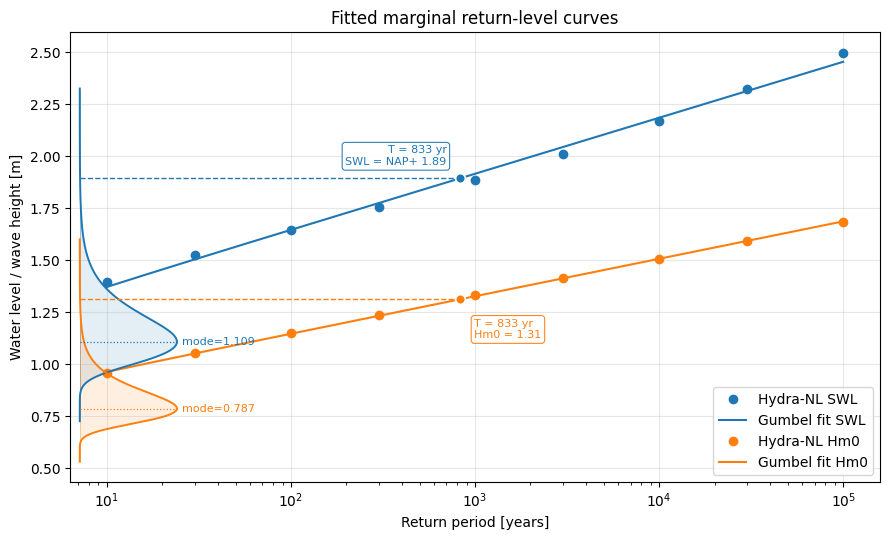

In [18]:
_ = plot_fitted_return_levels(
    margins,
    design_return_period=T_DESIGN,
)

## 4. Equal-quantile relation between $H_{m0}$ and $T_{m-1,0}$

The function `derive_tm_from_hm0` is imported from `Lsf_overtopping.py`.
$$
u_{wave}=F_{H_{m0}}(H_{m0}),
\qquad
T_{m-1,0}=F_T^{-1}(u_{wave}).
$$

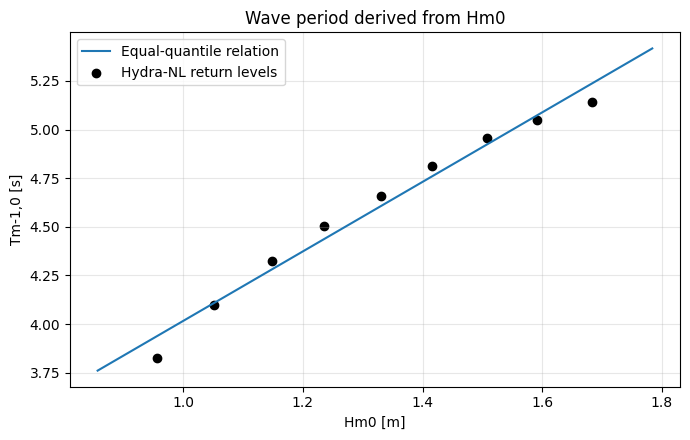

Tm-1,0 [s] = 2.229714 + 1.786428 * Hm0 [m]


In [19]:
def tm_hm0_coefficients(margins):
    """Return the linear relation implied by the two fitted Gumbel marginals."""
    slope = margins["Tm"].scale / margins["Hm0"].scale
    intercept = margins["Tm"].loc - slope * margins["Hm0"].loc
    return float(intercept), float(slope)


def plot_tm_hm0_relation(margins):
    """Plot the equal-quantile Hm0-Tm relation and Hydra-NL return-level pairs."""
    intercept, slope = tm_hm0_coefficients(margins)

    hm0_axis = np.linspace(
        HM0_RETURN_LEVEL[0] - 0.1,
        HM0_RETURN_LEVEL[-1] + 0.1,
        200,
    )
    tm_axis = derive_tm_from_hm0(hm0_axis, margins)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(hm0_axis, tm_axis, label="Equal-quantile relation")
    ax.scatter(
        HM0_RETURN_LEVEL,
        TM_RETURN_LEVEL,
        color="black",
        label="Hydra-NL return levels",
    )

    ax.set_xlabel("Hm0 [m]")
    ax.set_ylabel("Tm-1,0 [s]")
    ax.set_title("Wave period derived from Hm0")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    save_or_show(fig, "Tm_from_Hm0.png")
    return fig, intercept, slope


_, tm_intercept, tm_slope = plot_tm_hm0_relation(margins)

print(
    f"Tm-1,0 [s] = {tm_intercept:.6f} "
    f"+ {tm_slope:.6f} * Hm0 [m]"
)

## 5. Sector co-occurrence and correlation

The co-occurrence points and correlation functions are imported from `Lsf_overtopping.py`.

In [20]:
def build_dependence_table(margins):
    """Return the imported dependence calculation as a tidy DataFrame."""
    dependence = cooccurrence_dependence_table(margins)

    return pd.DataFrame(
        {
            "return_period_yr": dependence["return_period_yr"],
            "Hm0_m": dependence["Hm0"],
            "SWL_cooccurring_mNAP": dependence["SWL_cooccurring"],
            "SWL_return_period_yr": dependence["SWL_return_period_yr"].round(1),
            "rho_g": np.round(dependence["rho_g"], 3),
            "spearman_rho": np.round(dependence["spearman_rho"], 3),
        }
    )


dependence_table = build_dependence_table(margins)

rho_design = estimate_gaussian_copula_rho_from_cooccurrence(
    T_DESIGN,
    margins,
)
rho_far_tail = estimate_gaussian_copula_rho_from_cooccurrence(
    10_000.0,
    margins,
)

print(f"Derived Spearman rho at 1/{T_DESIGN:.0f} = {rho_design:.3f}")
print(f"Derived Spearman rho at 1/10000 = {rho_far_tail:.3f}")
print(
    "Rows below a 100-year return period and invalid or negative "
    "normal-score ratios are excluded from the positive-tail interpolation."
)

dependence_table

Derived Spearman rho at 1/833 = 0.366
Derived Spearman rho at 1/10000 = 0.396
Rows below a 100-year return period and invalid or negative normal-score ratios are excluded from the positive-tail interpolation.


,return_period_yr,Hm0_m,SWL_cooccurring_mNAP,SWL_return_period_yr,rho_g,spearman_rho
0,10.0,0.96,0.883509,1.0,-2.443,-1.000
1,100.0,1.15,1.112140,1.6,-0.132,-0.126
2,500.0,1.28,1.277551,4.8,0.277,0.266
3,833.0,1.32,1.347730,8.2,0.381,0.366
4,1000.0,1.33,1.374295,10.2,0.417,0.401
5,1500.0,1.36,1.199438,2.7,0.104,0.100
6,2000.0,1.38,1.229561,3.3,0.160,0.153
7,5000.0,1.45,1.339686,7.7,0.320,0.307
8,10000.0,1.51,1.429566,16.1,0.412,0.396


## 6. Joint distribution

In [21]:
def build_distribution_summary(margins, spearman_rho):
    """Summarise the exact hydraulic model passed to FORM."""
    latent_rho = spearman_to_gaussian_copula_rho(spearman_rho)
    intercept, slope = tm_hm0_coefficients(margins)

    return pd.DataFrame(
        [
            ["FORM vector", "X = [SWL, Hm0]", "implemented"],
            [
                "SWL marginal",
                f"Gumbel(loc={margins['SWL'].loc:.6f}, "
                f"scale={margins['SWL'].scale:.6f})",
                "fitted in Lsf_overtopping.py",
            ],
            [
                "Hm0 marginal",
                f"Gumbel(loc={margins['Hm0'].loc:.6f}, "
                f"scale={margins['Hm0'].scale:.6f})",
                "fitted in Lsf_overtopping.py",
            ],
            [
                "Copula",
                f"Gaussian(latent rho={latent_rho:.6f})",
                "constructed in Lsf_overtopping.py",
            ],
            [
                "Rank dependence",
                f"Spearman rho={spearman_rho:.6f}",
                "derived from sector co-occurrence",
            ],
            [
                "Tm relation",
                f"Tm={intercept:.6f}+{slope:.6f} Hm0",
                "equal-quantile mapping",
            ],
        ],
        columns=["component", "model", "status/source"],
    )


def plot_joint_cdf(margins, hydraulic_distribution, spearman_rho):
    """Plot CDF isolines in copula and physical coordinates."""
    ot.RandomGenerator.SetSeed(RANDOM_SEED)

    sample = np.asarray(
        hydraulic_distribution.getSample(PLOT_SAMPLES),
        dtype=float,
    )
    swl_sample = sample[:, 0]
    hm0_sample = sample[:, 1]

    u_sample = np.column_stack(
        [
            margins["SWL"].cdf(swl_sample),
            margins["Hm0"].cdf(hm0_sample),
        ]
    )
    hydra_u = np.column_stack(
        [
            margins["SWL"].cdf(SWL_RETURN_LEVEL),
            margins["Hm0"].cdf(HM0_RETURN_LEVEL),
        ]
    )

    u_axis = np.linspace(0.005, 0.99999, 140)
    v_axis = np.linspace(0.005, 0.99999, 140)
    u_grid, v_grid = np.meshgrid(u_axis, v_axis)

    uv_points = ot.Sample(
        np.column_stack([u_grid.ravel(), v_grid.ravel()]).tolist()
    )
    copula_cdf = np.asarray(
        hydraulic_distribution.getCopula().computeCDF(uv_points),
        dtype=float,
    ).reshape(u_grid.shape)

    swl_grid = margins["SWL"].ppf(u_grid)
    hm0_grid = margins["Hm0"].ppf(v_grid)
    cdf_levels = np.arange(0.1, 1.0, 0.1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(
        u_sample[:, 0],
        u_sample[:, 1],
        s=10,
        alpha=0.30,
        color="0.55",
        edgecolors="none",
        label="FORM-distribution samples",
    )
    axes[0].scatter(
        hydra_u[:, 0],
        hydra_u[:, 1],
        s=40,
        marker="^",
        color="black",
        label="Hydra-NL equal-return pairs",
    )
    contour_copula = axes[0].contour(
        u_grid,
        v_grid,
        copula_cdf,
        levels=cdf_levels,
        colors="tab:red",
        linestyles="dotted",
        linewidths=1.6,
    )
    axes[0].clabel(contour_copula, fmt="%.1f", fontsize=8)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("u = F_SWL(SWL)")
    axes[0].set_ylabel("v = F_Hm0(Hm0)")
    axes[0].set_title("Gaussian-copula CDF")
    axes[0].grid(color="0.75", linestyle="dotted", zorder=-1)
    axes[0].legend(loc="lower right")

    axes[1].scatter(
        swl_sample,
        hm0_sample,
        s=10,
        alpha=0.30,
        color="0.55",
        edgecolors="none",
        label="FORM-distribution samples",
    )
    axes[1].scatter(
        SWL_RETURN_LEVEL,
        HM0_RETURN_LEVEL,
        s=40,
        marker="^",
        color="black",
        label="Hydra-NL equal-return pairs",
    )
    contour_physical = axes[1].contour(
        swl_grid,
        hm0_grid,
        copula_cdf,
        levels=cdf_levels,
        colors="tab:red",
        linestyles="dotted",
        linewidths=1.6,
    )
    axes[1].clabel(contour_physical, fmt="%.1f", fontsize=8)
    axes[1].set_xlabel("SWL [m+NAP]")
    axes[1].set_ylabel("Hm0 [m]")
    axes[1].set_title("Joint CDF in the physical domain")
    axes[1].grid(color="0.75", linestyle="dotted", zorder=-1)
    axes[1].legend(loc="lower right")

    fig.suptitle(
        f"CDF isolines of the FORM input distribution "
        f"(Spearman rho={spearman_rho:.3f})"
    )

    fig.tight_layout()
    save_or_show(fig, "CDFcopula.png")
    return fig


latent_rho = spearman_to_gaussian_copula_rho(rho_design)

hydraulic_distribution = build_openturns_hydraulic_distribution(
    spearman_rho=rho_design,
    margins=margins,
)

distribution_summary = build_distribution_summary(
    margins,
    rho_design,
)

print(hydraulic_distribution)
print(
    "Physical-space Pearson correlation reported by OpenTURNS: "
    f"{hydraulic_distribution.getCorrelation()[0, 1]:.6f}"
)

distribution_summary

JointDistribution(Gumbel(beta = 0.11691, gamma = 1.1087), Gumbel(beta = 0.0781716, gamma = 0.787282), NormalCopula(R = [[ 1        0.381355 ]
 [ 0.381355 1        ]]))
Physical-space Pearson correlation reported by OpenTURNS: 0.357027


,component,model,status/source
0,FORM vector,"X = [SWL, Hm0]",implemented
1,SWL marginal,"Gumbel(loc=1.108703, scale=0.116910)",fitted in Lsf_overtopping.py
2,Hm0 marginal,"Gumbel(loc=0.787282, scale=0.078172)",fitted in Lsf_overtopping.py
3,Copula,Gaussian(latent rho=0.381355),constructed in Lsf_overtopping.py
4,Rank dependence,Spearman rho=0.366410,derived from sector co-occurrence
5,Tm relation,Tm=2.229714+1.786428 Hm0,equal-quantile mapping


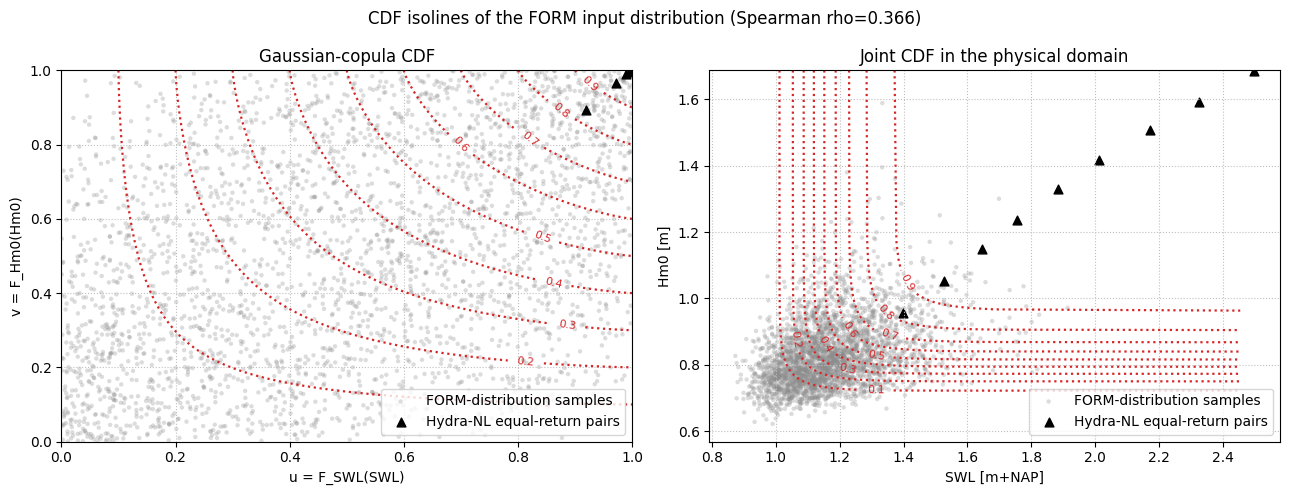

In [22]:
_ = plot_joint_cdf(
    margins,
    hydraulic_distribution,
    rho_design,
)

## 7. EurOtop overtopping response surface

Both `compute_q` and `derive_tm_from_hm0` are imported from `Lsf_overtopping.py`.

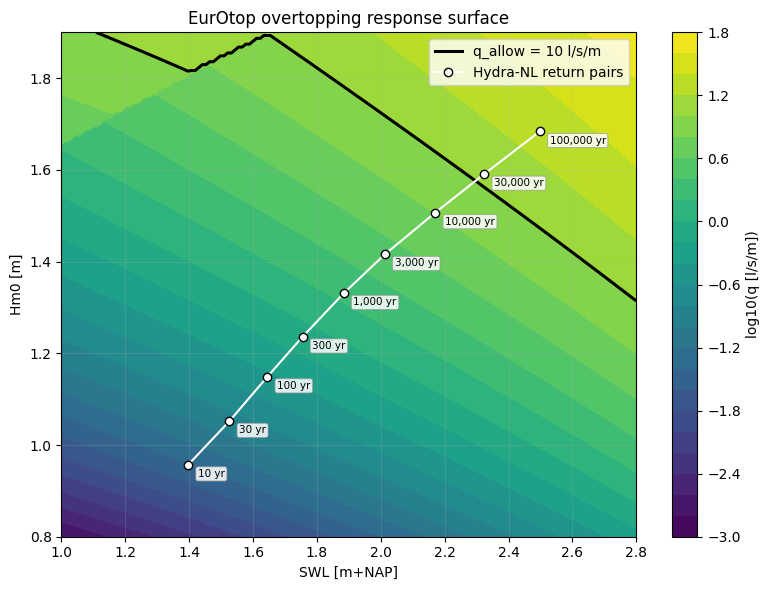

In [23]:
def create_response_grid(config, margins, grid_size=RESPONSE_GRID_SIZE):
    """Calculate q over an SWL-Hm0 grid."""
    swl_axis = np.linspace(*SWL_RESPONSE_BOUNDS, grid_size)
    hm0_axis = np.linspace(*HM0_RESPONSE_BOUNDS, grid_size)

    swl_grid, hm0_grid = np.meshgrid(swl_axis, hm0_axis)
    tm_grid = derive_tm_from_hm0(hm0_grid, margins)

    q_grid, regime_grid = compute_q(
        swl_grid,
        hm0_grid,
        tm_grid,
        z_crest=config.z_crest,
        z_bed=config.z_bed,
        g=config.g,
    )

    return swl_grid, hm0_grid, tm_grid, q_grid, regime_grid


def plot_response_surface(config, margins):
    """Plot the overtopping response and allowable-discharge contour."""
    swl_grid, hm0_grid, _, q_grid, _ = create_response_grid(
        config,
        margins,
    )

    q_l_s_m = q_grid * 1000.0
    log_q = np.log10(np.maximum(q_l_s_m, 1.0e-8))

    fig, ax = plt.subplots(figsize=(8, 6))

    filled = ax.contourf(
        swl_grid,
        hm0_grid,
        log_q,
        levels=25,
    )
    fig.colorbar(
        filled,
        ax=ax,
        label="log10(q [l/s/m])",
    )

    ax.contour(
        swl_grid,
        hm0_grid,
        q_l_s_m,
        levels=[config.q_allow * 1000.0],
        colors="black",
        linewidths=2.2,
    )
    ax.plot(
        [],
        [],
        color="black",
        linewidth=2.2,
        label=f"q_allow = {config.q_allow * 1000.0:g} l/s/m",
    )

    ax.plot(
        SWL_RETURN_LEVEL,
        HM0_RETURN_LEVEL,
        "wo-",
        markeredgecolor="black",
        label="Hydra-NL return pairs",
    )

    for return_period, swl_value, hm0_value in zip(
        RETURN_PERIOD_YR,
        SWL_RETURN_LEVEL,
        HM0_RETURN_LEVEL,
    ):
        ax.annotate(
            f"{return_period:,.0f} yr",
            (swl_value, hm0_value),
            textcoords="offset points",
            xytext=(7, -3),
            fontsize=7.5,
            color="black",
            zorder=6,
            ha="left",
            va="top",
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "0.6",
                "linewidth": 0.6,
                "alpha": 0.85,
            },
        )

    ax.set_xlabel("SWL [m+NAP]")
    ax.set_ylabel("Hm0 [m]")
    ax.set_title("EurOtop overtopping response surface")
    ax.grid(True, alpha=0.2)
    ax.legend()

    fig.tight_layout()
    save_or_show(fig, "responsesurface.png")
    return fig


_ = plot_response_surface(config, margins)

## 8. Interpretation

- **What is fitted?** The Gumbel marginal return-level curves for SWL, Hm0 and Tm.
- **What is derived (not assumed)?** The Gaussian-copula correlation, from the Hydra-NL
  co-occurrence illustration points weighted score method:
  Spearman rho ~0.37 at the 1/833 design frequency and ~0.40 toward 1/10,000 (non-monotone, with a
  dip near 1/1500-1/2000).
- **Why is a single rho only approximate?** The SWL-Hm0 dependence is regime-dependent because
  extreme water is meerpeil-driven (few waves) while extreme waves are wind-driven; the two
  coincide only in the far storm tail (Achtergrond rapport Deltares 2017, sec. 2.3.4).
- **Which directions govern the face?** The 0-100 degree fetch/wave-attack sector. The co-occurrence
  derivation uses the in-sector Hydra-NL bins 30, 60 and 90 degrees. the 120 bin does not contain any weight so its discarded. 
- **What relation is used for the period?** `Tm = 2.229714 + 1.786428 Hm0`, by fitted wave marginals.
- **What enters FORM?** Only `X = [SWL, Hm0]`; Tm is computed inside the overtopping limit-state
  function.
- **When does overtopping become a problem?** With the adopted q_allow = 0.01l/s/m a Waveheight of > 1.65 m together with a SWL >   NAP+2.30 m

## Upper-tail depence CvM test 
$$
P(U>t\mid V>t)=\frac{1-2t+C(t,t)}{1-t}.
$$